# WP3 (shots budget) + WP6 (dequantisation) — the honest readout accounting

The referee question both papers 1–2 faced, now quantified for the comb: *what does
it cost to actually read the answer out, and what exactly is the quantum content?*

**The readout model.** A successful post-selection (probability
$p_{\rm succ} = \|p(X)b\|^2/\|c\|_1^2 \approx 0.44/T$, measured) leaves the
normalised filtered state; measuring the system register draws segment $i$ with
probability $\pi_i = |x^f_i|^2 / \|x^f\|^2$. The comb concentrates this mass on the
~4T true segments, so the practical task — *identify the active set* — is a
coupon-collector problem over ≈ 4T near-uniform cells.

In [1]:
import sys
for p in ("/data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/_shared",
          "/data/bfys/gscriven/LHCb_VeLo_Toy_Model/src"):
    if p not in sys.path: sys.path.insert(0,p)
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import qtrk_pipeline as qp
plt.rcParams.update({"figure.dpi":115,"font.size":11,"axes.grid":True,"grid.alpha":0.3})
OUT=Path("/data/bfys/gscriven/Quantum_Track_Reconstruction/QSVT/Paper_planning/outputs")
TAU=qp.threshold_for(3.0,1.0)
# measured post-selected mass distribution from a stored comb solution (T=400, gamma=3, clean)
sols=pd.read_csv(qp.manifest_dir()/"solutions.csv")
r=sols[(sols.solver=="qsvt")&(sols.study=="Verify_new_results")&(sols.n_trk==400)&
       (sols.gamma==3.0)&(sols.hit_ineff==0.0)&(sols.rep==0)].iloc[0]
d=qp.load_solution(r.sol_key); x=np.asarray(d["sol"],float)  # unit-norm |amplitudes|
ev,_=qp.ensure_event(n_trk=400,rep=0,sigma_scatt=1e-4,sigma_res=0.0,phi_max=0.2,hit_ineff=0.0)
truth=np.asarray(qp.truth_from_event(ev),bool)
pi=x**2/np.sum(x**2)
mass_true=float(pi[truth].sum())
print(f"T=400 stored comb solution: post-selected probability mass on TRUE segments = {mass_true:.3f}")
print(f"effective true cells: {1/np.sum(pi[truth]**2)/ (pi[truth].sum()**-2 * len(pi[truth])**0) :.0f} "
      f"(participation ratio {1/np.sum((pi[truth]/pi[truth].sum())**2):.0f} of {truth.sum()})")
P_anc=float(d["P_anc"]); print(f"measured p_succ = {P_anc:.5f}  (0.44/T = {0.44/400:.5f})")

T=400 stored comb solution: post-selected probability mass on TRUE segments = 0.988
effective true cells: 1503 (participation ratio 1503 of 1600)
measured p_succ = 0.00109  (0.44/T = 0.00110)


## 1. Shots vs T — the WP3 classical floor

Coverage of the active set (see every true segment ≥ once with probability
1−1/4T): successful samples $\;n_s \approx N_a \ln(N_a^2) \approx 2 N_a \ln N_a$
with $N_a \approx 4T$ effective cells. Three readout strategies:

- **bare sampling:** raw shots $= n_s / p_{\rm succ}$;
- **amplitude amplification (AA):** $\lceil \pi/(4\sqrt{p_{\rm succ}}) \rceil$
  walk-sequence rounds turn each shot into a near-certain success — total *walk
  calls* $= n_s \cdot d \cdot O(1/\sqrt{p_{\rm succ}})$;
- **classical exact:** the same Chebyshev recursion on a CPU, $d$ sparse matvecs,
  $O(d \cdot \mathrm{nnz}(A))$ float-ops, returns *all* amplitudes deterministically
  (measured 1.6 s at T = 1000).

   T  p_succ  cover_samples  shots_bare  AA_rounds  walk_calls_with_AA  classical_flops
  50 0.00880           2145      243749          9              772200          1200000
 100 0.00440           4853     1102954         12             2329440          4800000
 200 0.00220          10829     4922272         17             7363720         19200000
 400 0.00110          23905    21731818         24            22948800         76800000
 700 0.00063          45007    71602045         32            57608960        235200000
1000 0.00044          67185   152693181         38           102121200        480000000


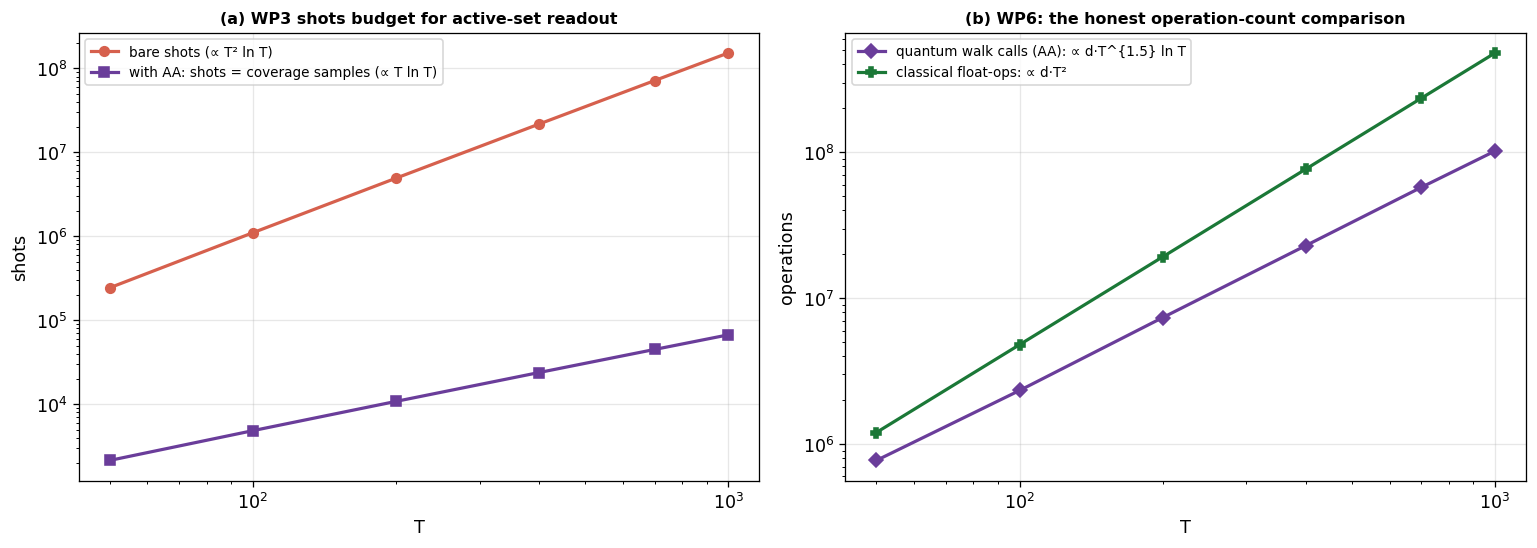

saved wp36_readout_dequantisation


In [2]:
Ts=np.array([50,100,200,400,700,1000]); deg=40
Na=4*Ts; ns=(2*Na*np.log(Na)/mass_true).astype(int)        # successful samples for coverage
p=0.44/Ts
shots_bare=(ns/p).astype(int)
aa_rounds=np.ceil(np.pi/(4*np.sqrt(p))).astype(int)
walk_calls_aa=(ns*deg*aa_rounds).astype(int)
classical_ops=(deg*4*Ts**2*3).astype(int)                  # d x nnz(A) x ~3 flops/nz
TBL=pd.DataFrame(dict(T=Ts,p_succ=np.round(p,5),cover_samples=ns,
                      shots_bare=shots_bare,AA_rounds=aa_rounds,
                      walk_calls_with_AA=walk_calls_aa,classical_flops=classical_ops))
print(TBL.to_string(index=False))
fig,ax=plt.subplots(1,2,figsize=(13.5,4.9))
ax[0].loglog(Ts,shots_bare,'o-',color="#d6604d",lw=2,label="bare shots (∝ T² ln T)")
ax[0].loglog(Ts,ns,'s-',color="#6a3d9a",lw=2,label="with AA: shots = coverage samples (∝ T ln T)")
ax[0].set_xlabel("T"); ax[0].set_ylabel("shots"); ax[0].legend(fontsize=8.5)
ax[0].set_title("(a) WP3 shots budget for active-set readout",fontweight="bold",fontsize=10)
ax[1].loglog(Ts,walk_calls_aa,'D-',color="#6a3d9a",lw=2,label="quantum walk calls (AA): ∝ d·T^{1.5} ln T")
ax[1].loglog(Ts,classical_ops,'P-',color="#1b7837",lw=2,label="classical float-ops: ∝ d·T²")
ax[1].set_xlabel("T"); ax[1].set_ylabel("operations"); ax[1].legend(fontsize=8.5)
ax[1].set_title("(b) WP6: the honest operation-count comparison",fontweight="bold",fontsize=10)
fig.tight_layout()
for e,dp in (("pdf",600),("png",300)): fig.savefig(OUT/f"wp36_readout_dequantisation.{e}",dpi=dp,bbox_inches="tight",facecolor="white")
plt.show(); print("saved wp36_readout_dequantisation")

## 2. The dequantisation statement (WP6), stated for the paper

1. **The response is solver-agnostic.** Our own production pipeline applies the
   comb *classically*: the Chebyshev recursion is $d$ sparse matvecs,
   $O(d\cdot\mathrm{nnz}(A)) = O(d\,n_{\rm seg})$ float-ops, deterministic, all
   amplitudes at once (1.6 s at T = 1000 on one core). **There is no claim that the
   comb's discrimination is quantum** — it is a filter-design result.
2. **The quantum content is the resource profile.** Width $\lceil\log_2 n\rceil+7$
   qubits vs $O(n)$ memory; and for *active-set readout with amplitude
   amplification*, total walk calls scale as
   $\;n_s \cdot d \cdot O(1/\sqrt{p}) \sim d\,T^{1.5}\ln T\;$ vs the classical
   $d\,T^2$ — a genuine $\sqrt T$-class separation **for this readout task**, with
   the same caveats as papers 1–2: constant factors, the uniform-$b$ state prep
   (trivial here — Hadamards), no QRAM needed (the oracle is the geometric hit
   adjacency), and coherence long enough for $d\cdot O(\sqrt T)$ walk steps.
3. **What would kill it:** asking for all amplitude *values* (not the set) restores
   $T^2$ sampling; classical sub-linear heuristics on the sparse graph (union-find
   on the ε-window adjacency is $O(n\,\alpha(n))$ and solves much of the same
   problem). The defensible claim is the **resource-profile** one, stated exactly
   as above — not a beyond-classical discrimination claim.